<center>Association of Structural Engineers of the Philippines, Inc.</center>
<center>Committee on Continuing Professional Development</center>
<center><b>Python Workshop Series for Structural Engineers</b></center>
<center><b>Day 3: Programming Competition</b></center>

**Introduction**. Welcome, fellow future Pythonistas, to the third day of the workshop! In this session, you will apply what you have learned from Day 1 and Day 2 sessions thru a programming competition that combines Python coding with a real-life structural engineering problem. Please read carefully all instructions indicated in this notebook, and work with your team through completion of all prompts. Please also refer to the competition mechanics for more details. Special prizes await for the top teams, which will be awarded before the session ends. Good luck and enjoy coding!

<div align="right">- The ASEP Python Team (Tabong, Lucero, Pamonag, Ipa)</div>

In [ ]:
# IMPORTS AND UNITS

# The following libraries are already pre-imported to this notebook.
# Should you wish to import additional libraries, please do so here.
# However, please DO NOT delete the `import ...` lines that are already
# here in this notebook.
# 
import copy
import math

import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as shp
import tkinter as tk
import plotly
import ipywidgets
import pytest

#
# The base units for this notebook are Newtons (N) and meters (m)
# You may use the variable assignments below to visually add units
# to your numerical quantities.  For example,
# 
# force = 0.5*kN        # means convert 0.5 kN to N
# E = 200*GPa           # means convert 200 GPa to Pa (N/m^2)
#
# b = 0.6*to_mm         # means convert 0.6 m to mm
# moment = 200*to_kN*m  # means convert 200 N-m to kN-m
#
m, to_m =[1, 1]
mm, to_mm = [1e-3, 1e3]
N, to_N = [1, 1]
kN, to_kN = [1e3, 1e-3]
kPa, to_kPa = [1e3, 1e-3]
MPa, to_MPa = [1e6, 1e-6]
GPa, to_GPa = [1e9, 1e-9]

### **Situation**

You are given a reinforced concrete rectangular beam that is pin-supported at one point within the length and roller-supported at another point within the length. The goal is to draw the beam and its loads, analyze the beam for gravity loads, and design the beam for flexure and shear. The following quantities shall be given by the user.

- `L` (float) is the length of the beam ($L > 0$)
- `x_sup1` (float) is the location of the left support measured from the left end of the beam ($0 \leqslant x_\text{sup1} \leqslant L$)
- `x_sup2` (float) is the location of the right support measured from the left end of the beam ($0 \leqslant x_\text{sup2} \leqslant L$, $x_\text{sup2}> x_\text{sup1}$)
- `loads` (two-dimensional list) is the list of *unfactored* loads applied to the beam. Each item in `loads` is another list of the form `[A, B, C, D]`, where
    - `A` (string) is the degree of the load, which can be either `"point"`, `"uniform"` or `"moment"`
    - `B` (string) is the type of the load, which can be either `"dead"` or `"live"`
    - `C` (float) is the value of the load in their respective units ($C \geqslant 0$)
        - For `"point"` and `"uniform"` loads, positive load is upward, while negative load is downward.
        - For `"moment"` loads, positive load is counterclockwise, while negative load is clockwise.
    - `D` (float) is the location of the load measured from the left end of the beam ($0 \leqslant D \leqslant L$)
        - For `"uniform"` loads, `D` is instead a (tuple) containing two items: the starting point, and ending point of the uniform load
- `fcp` (float) is the 28-day compressive strength of concrete ($f'_c > 0$)
- `fy` (float) is the main reinforcement yield strength ($f_y > 0$)
- `fyt` (float) is the transverse reinforcement yield strength ($f_{yt} > 0$)
- `cc` (float) is the clear concrete cover ($c_c > 0$). Assume clear cover is the same on all sides of the beam.
- `db` (float) is the diameter of the main reinforcement ($d_b > 0$). Assume diameter is the same for both top and bottom bars.
- `dst` (float) is the diameter of the transverse reinforcement ($d_{st} > 0$).

The examples in the following problems are generated from the following three test beams. Feel free to use them in debugging your programs.

In [ ]:
# Test beam #1: Uniform load only, no overhang.

L_1 = 8*m
x_sup1_1 = 0*m
x_sup2_1 = L_1

loads_1 = [
    ["uniform", "dead", -15*kN/m, (0, L_1)],
    ["uniform", "live", -40*kN/m, (0, L_1)]
]

fcp_1, fy_1, fyt_1, cc_1, db_1, dst_1 = 20.7*MPa, 415*MPa, 275*MPa, 40*mm, 16*mm, 10*mm

In [ ]:
# Test beam #2: Uniform load with point loads, one overhang.

L_2 = 10*m
x_sup1_2 = 0*m
x_sup2_2 = L_2 - 3*m

loads_2 = [
    ["uniform", "dead", -20*kN/m, (2*L_2/3, L_2)],
    ["uniform", "live", -30*kN/m, (2*L_2/3, L_2)],
    ["point", "dead", -120*kN, L_2/3],
    ["point", "live", -250*kN, L_2/3],
]

fcp_2, fy_2, fyt_2, cc_2, db_2, dst_2 = 34.5*MPa, 415*MPa, 275*MPa, 40*mm, 20*mm, 12*mm

In [ ]:
# Test beam #3: General beam loading, two overhangs.
 
L_3 = 6*m
x_sup1_3 = 2*m
x_sup2_3 = L_3 - 2*m

loads_3 = [
    ["point",   "dead", 30*kN,      2*m],
    ["point",   "live", -40*kN,     3*m],
    ["uniform", "dead", -15*kN/m,   (1*m, 4*m)],
    ["uniform", "live", 10*kN/m,    (4.5*m, L_3)],
    ["moment",  "dead", 20*kN*m,    4*m],
    ["moment",  "live", -25*kN*m,   0.5*m]
]

fcp_3, fy_3, fyt_3, cc_3, db_3, dst_3 = 27.6*MPa, 415*MPa, 275*MPa, 50*mm, 25*mm, 12*mm

##### **Problem 1** (10 points)

Create a function named `plot_beam` that accepts `L`, `x_sup1`, `x_sup2` and `loads` as required arguments, and an optional argument `scale` with default value of 1. The function shall return a plot of the beam, together with its supports and applied loads. You may use either `matplotlib` or `plotly` to do this visualization.
- Feel free to use `scale` to adjust the height of the loads in the plot so that it fits in the plot window.

**For plus points**: You may also use `ipywidgets` to make the beam visualization more interactive. However, please ensure that no `ipywidgets` functions are present inside the `plot_beam` function.

Refer to the figures below for examples.

*Test beam #1*

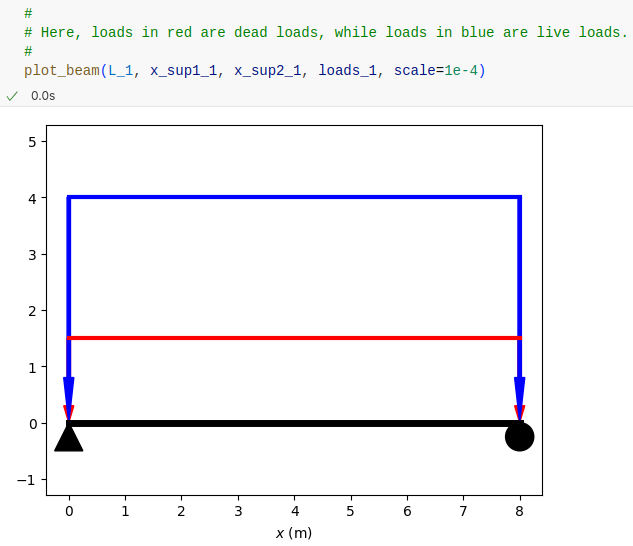

*Test beam #2*

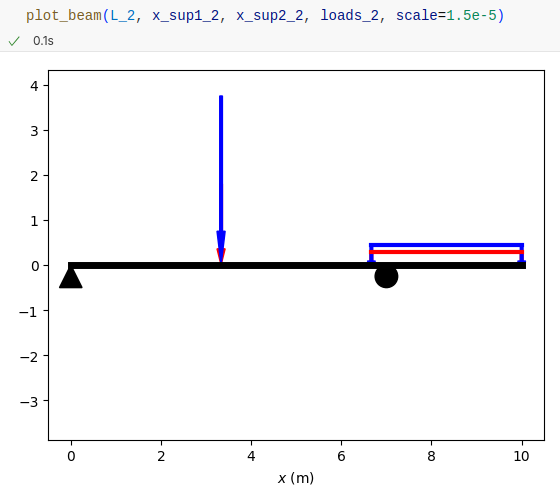

*Test beam #3*

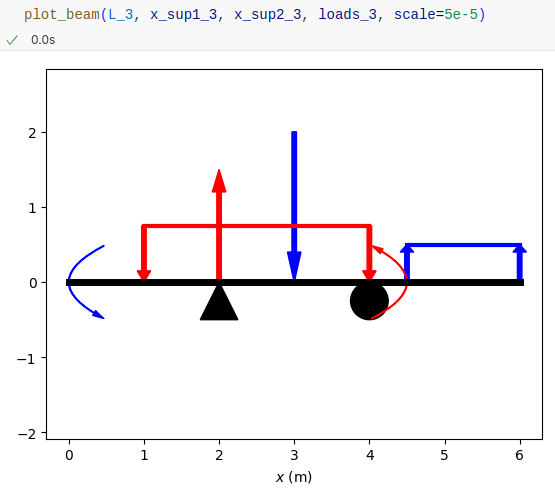

In [ ]:
def plot_beam(L, x_sup1, x_sup2, loads, scale=1) :
    #
    # Place your code here.
    #

    return None

In [ ]:
# Test beam #1
# Here, loads in red are dead loads, while loads in blue are live loads.
#
plot_beam(L_1, x_sup1_1, x_sup2_1, loads_1, scale=1e-4)

In [ ]:
# Test beam #2
plot_beam(L_2, x_sup1_2, x_sup2_2, loads_2, scale=1.5e-5)

In [ ]:
# Test beam #3
plot_beam(L_3, x_sup1_3, x_sup2_3, loads_3, scale=5e-5)

##### **Problem 2** (10 points)

Create a function called `factored_loads` that takes `loads` as a required argument and returns a (tuple) `(asd1, asd2, lrfd1, lrfd2)` containing the factored loads of the beam in base units N and m. `asd1`, `asd2`, `lrfd1`, `lrfd2` shall all be (two-dimensional lists), which shall be constructed subject to the following:

- Remove all `"dead"` or `"live"` items from the `loads` list.
- Multiply each load value by the corresponding load factor in the following manner:
    - For load combination `asd1`: Multiply values of all `"dead"` loads by 1.0, delete all `"live"` loads from the list.
    - For load combination `asd2`: Multiply values of all `"dead"` loads by 1.0, multiply values of all `"live"` loads by 1.0.
    - For load combination `lrfd1`: Multiply values of all `"dead"` loads by 1.4, delete all `"live"` loads from the list.
    - For load combination `lrfd2`: Multiply values of all `"dead"` loads by 1.2, multiply values of all `"live"` loads by 1.6.

Refer to the figure below for examples.

*Test beam #1*

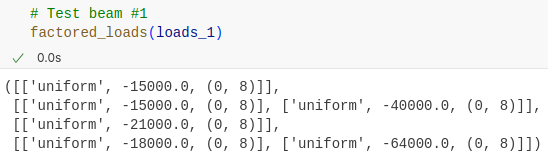

*Test beam #2*

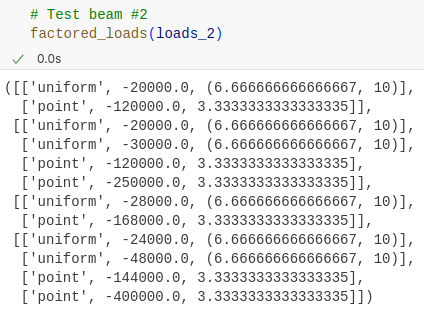

*Test beam #3*

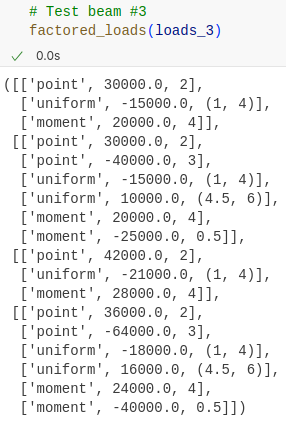

In [ ]:
def factored_loads(loads) :
    #
    # Use the following copies of loads for each load combination 
    # so as not to directly modify loads and affect the results
    # of the next problems.
    #
    loads_for_asd1 = copy.deepcopy(loads)
    loads_for_asd2 = copy.deepcopy(loads)
    loads_for_lrfd1 = copy.deepcopy(loads)
    loads_for_lrfd2 = copy.deepcopy(loads)

    #
    # Place your code here.
    #

    return (asd1, asd2, lrfd1, lrfd2)

In [ ]:
# Test beam #1
factored_loads(loads_1)

In [ ]:
# Test beam #2
factored_loads(loads_2)

In [ ]:
# Test beam #3
factored_loads(loads_3)

##### **Problem 3** (40 points)

**Part A.** Create a function called `support_reactions` that takes `factored_loads`, `x_sup1` and `x_sup2` as required arguments, and returns a (tuple) `(reactions_sup1, reactions_sup2)` in base unit N. `reactions_sup1` contains the reactions for the left support, while `reactions_sup2` contains the reactions for the right support. Each of them is a list of four items, with each item corresponding to each of the four load combinations `asd1`, `asd2`, `lrfd1` and `lrfd2`, respectively, as defined in Problem 2.

Refer to the figure below for examples.

*Test beam #1*

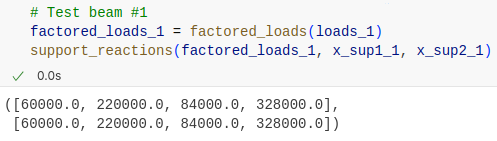

*Test beam #2*

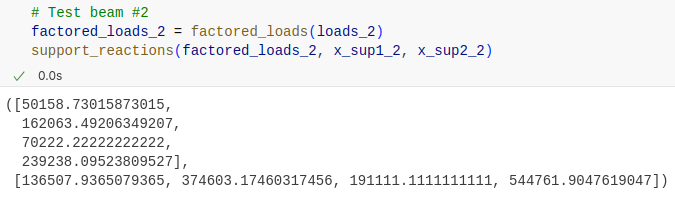

*Test beam #3*

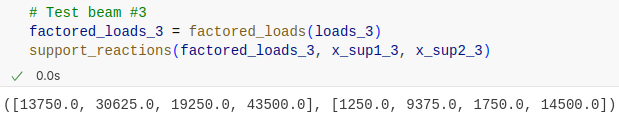

In [ ]:
#
# Note: factored_loads should directly come from the results of Problem 2.
#
def support_reactions(factored_loads, x_sup1, x_sup2) :
    #
    # Place your code here.
    #

    return (reactions_sup1, reactions_sup2)

In [ ]:
# Test beam #1
factored_loads_1 = factored_loads(loads_1)
support_reactions(factored_loads_1, x_sup1_1, x_sup2_1)

In [ ]:
# Test beam #2
factored_loads_2 = factored_loads(loads_2)
support_reactions(factored_loads_2, x_sup1_2, x_sup2_2)

In [ ]:
# Test beam #3
factored_loads_3 = factored_loads(loads_3)
support_reactions(factored_loads_3, x_sup1_3, x_sup2_3)

**Part B.** Create a function called `updated_factored_loads` that takes `factored_loads`, `reactions_sup1`, `reactions_sup2`, `x_sup1`, and `x_sup2` as required arguments, and returns an updated `factored_loads` with the support reactions incorporated in there. Treat support reactions as `"point"` loads.

Refer to the figures below as examples.

*Test beam #1*

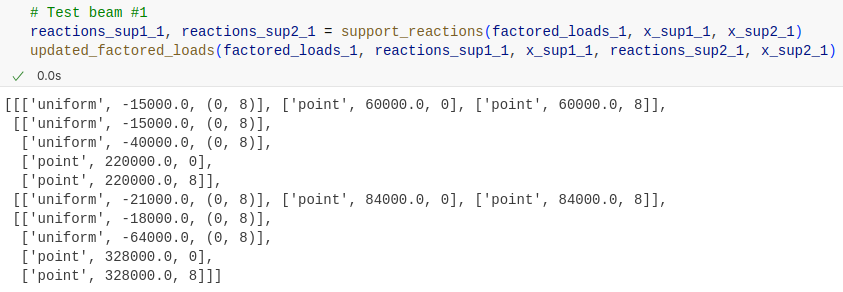

*Test beam #2*

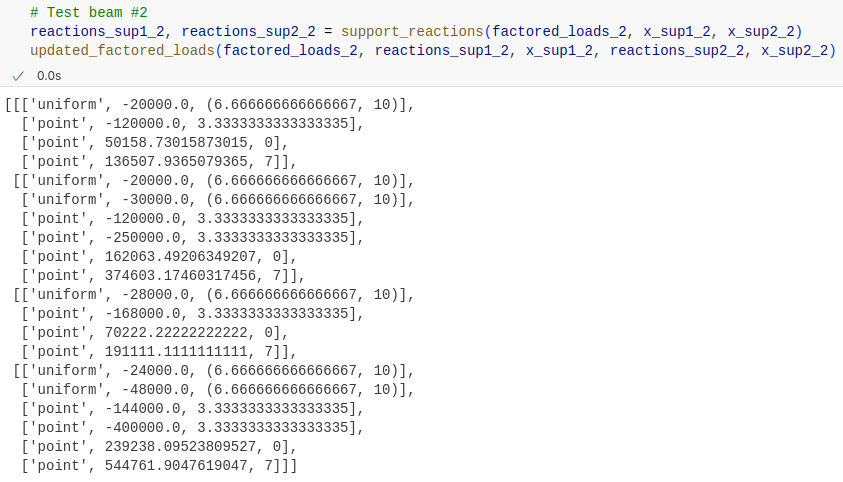

*Test beam #3*

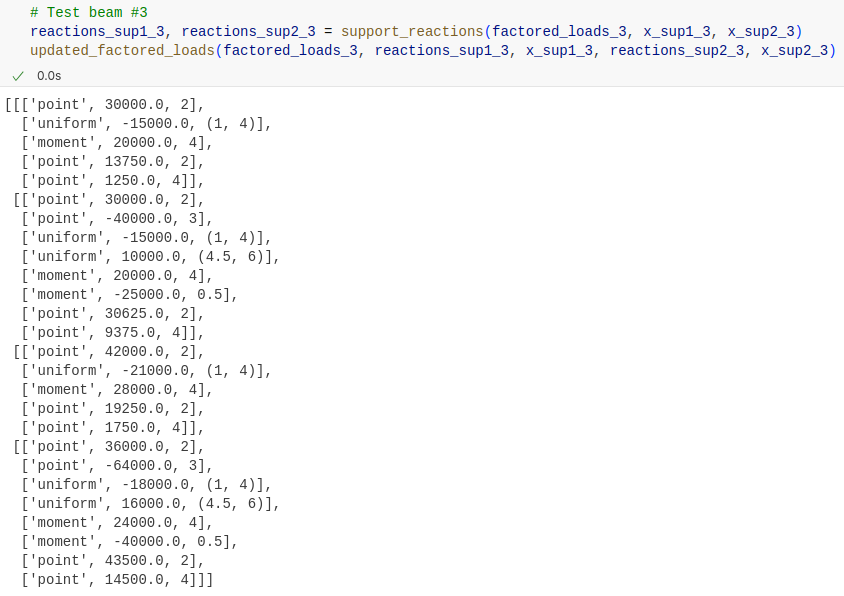

In [ ]:
def updated_factored_loads(factored_loads, reactions_sup1, x_sup1, reactions_sup2, x_sup2) :
    #
    # Place your code here.
    #
    
    return factored_loads

In [ ]:
# Test beam #1
reactions_sup1_1, reactions_sup2_1 = support_reactions(factored_loads_1, x_sup1_1, x_sup2_1)
updated_factored_loads(factored_loads_1, reactions_sup1_1, x_sup1_1, reactions_sup2_1, x_sup2_1)

In [ ]:
# Test beam #2
reactions_sup1_2, reactions_sup2_2 = support_reactions(factored_loads_2, x_sup1_2, x_sup2_2)
updated_factored_loads(factored_loads_2, reactions_sup1_2, x_sup1_2, reactions_sup2_2, x_sup2_2)

In [ ]:
# Test beam #3
reactions_sup1_3, reactions_sup2_3 = support_reactions(factored_loads_3, x_sup1_3, x_sup2_3)
updated_factored_loads(factored_loads_3, reactions_sup1_3, x_sup1_3, reactions_sup2_3, x_sup2_3)

**Part C.**

(a) Create a function called `factored_shear` that takes two required arguments `factored_loads` and `L`, and one optional argument `n_points`, where the beam is divided into `n_points` number of points of equal spacing. The function shall return a tuple named `shear_ = (shear_asd1, shear_asd2, shear_lrfd1, shear_lrfd2)` which contains the results for each load combination described in Problem 2. Each of `shear_asd1`, `shear_asd2`, `shear_lrfd1`, `shear_lrfd2` shall be a list containing the values of shear force in base unit N for the `n_points` points of the beam.

(b) Create a function called `factored_moment` that takes two required arguments `factored_loads` and `L`, and one optional argument `n_points`, where the beam is divided into `n_points` number of points of equal spacing. The function shall return a tuple `moment_ = (moment_asd1, moment_asd2, moment_lrfd1, moment_lrfd2)` which contains the results for each load combination described in Problem 2. Each of `moment_asd1`, `moment_asd2`, `moment_lrfd1`, `moment_lrfd2` shall be a list containing the values of bending moment in base unit N-m for the `n_points` points of the beam.

Refer to the figures below for examples.

<u>*Test beam #1*</u>

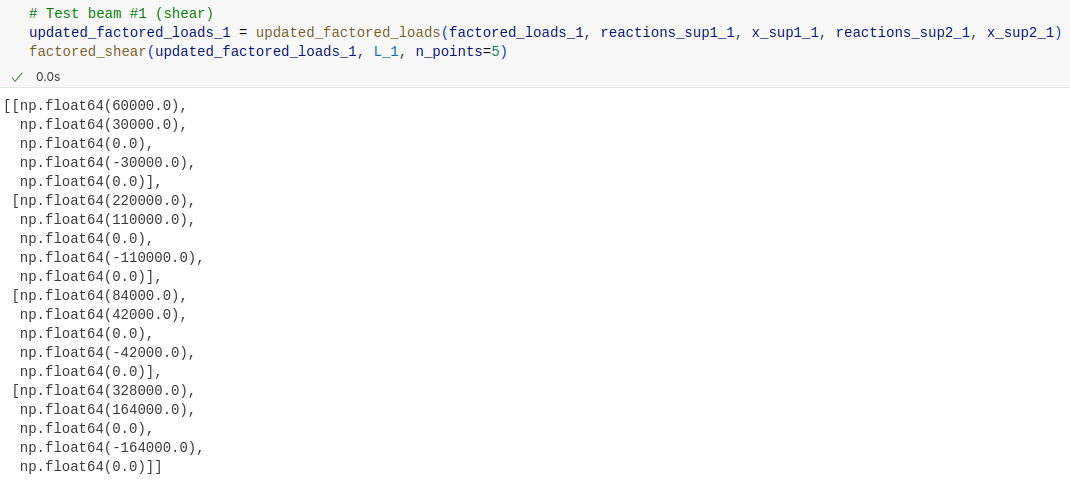 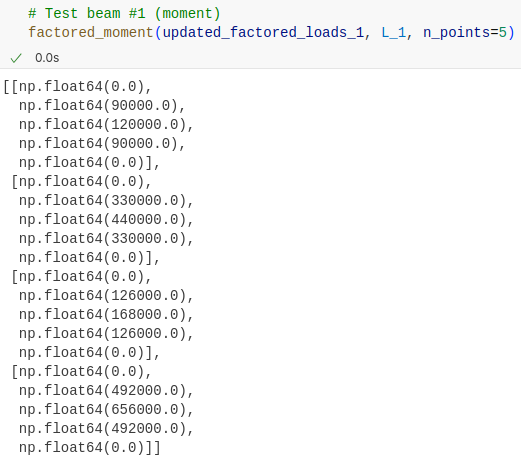

<u>*Test beam #2*</u>

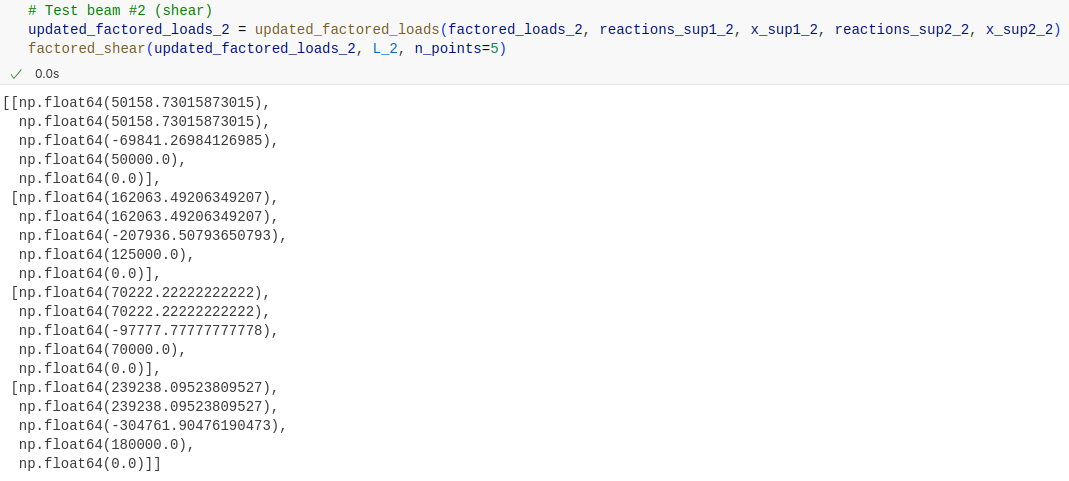 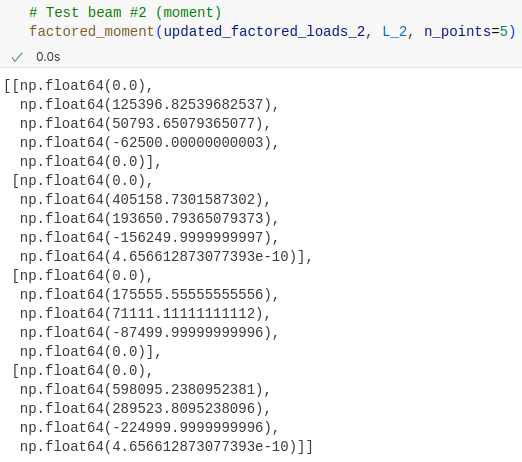

<u>*Test beam #3*</u>

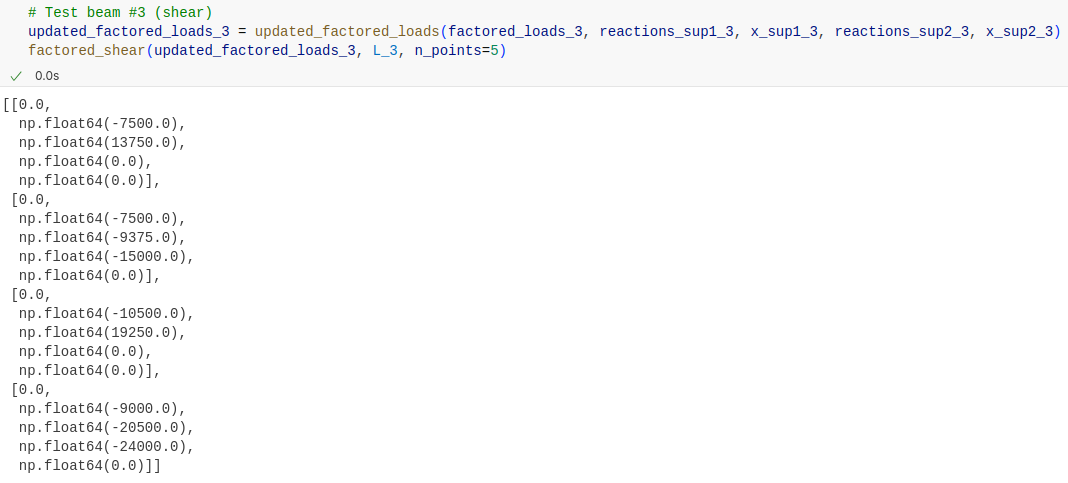 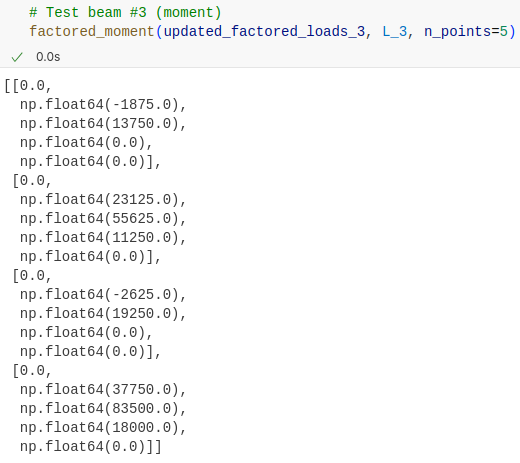

In [ ]:
#
# If you have additional functions that you want to create that `factored_shear` and
# `factored_moment` will use, place your code here.
#

def factored_shear(factored_loads, L, n_points=100) :
    #
    # Place your code here.
    #

    return shear_

def factored_moment(factored_loads, L, n_points=100) :
    #
    # Place your code here.
    #

    return moment_

In [ ]:
# Test beam #1 (shear)
updated_factored_loads_1 = updated_factored_loads(factored_loads_1, reactions_sup1_1, x_sup1_1, reactions_sup2_1, x_sup2_1)
factored_shear(updated_factored_loads_1, L_1, n_points=5)

In [ ]:
# Test beam #1 (moment)
factored_moment(updated_factored_loads_1, L_1, n_points=5)

In [ ]:
# Test beam #2 (shear)
updated_factored_loads_2 = updated_factored_loads(factored_loads_2, reactions_sup1_2, x_sup1_2, reactions_sup2_2, x_sup2_2)
factored_shear(updated_factored_loads_2, L_2, n_points=5)

In [ ]:
# Test beam #2 (moment)
factored_moment(updated_factored_loads_2, L_2, n_points=5)

In [ ]:
# Test beam #3 (shear)
updated_factored_loads_3 = updated_factored_loads(factored_loads_3, reactions_sup1_3, x_sup1_3, reactions_sup2_3, x_sup2_3)
factored_shear(updated_factored_loads_3, L_3, n_points=5)

In [ ]:
# Test beam #3 (moment)
factored_moment(updated_factored_loads_3, L_3, n_points=5)

**Part D.** 

(a) Create a function called `plot_shear_diagram` that takes the tuple `updated_factored_loads` from Problem 3 Part B and `L` as required arguments, and `n_points` as an optional argument, and returns the plot of the shear diagram for the four load combinations described in Problem 2.

(a) Create a function called `plot_moment_diagram` that takes the tuple `updated_factored_loads` from Problem 3 Part B and `L` as required arguments, and `n_points` as an optional argument, and returns the plot of the bending moment diagram for the four load combinations described in Problem 2.

Use `matplotlib` or `plotly` for both prompts, and customize the plots in any way you want.

Refer to the figures below for examples.

<u>*Test beam #1*</u>

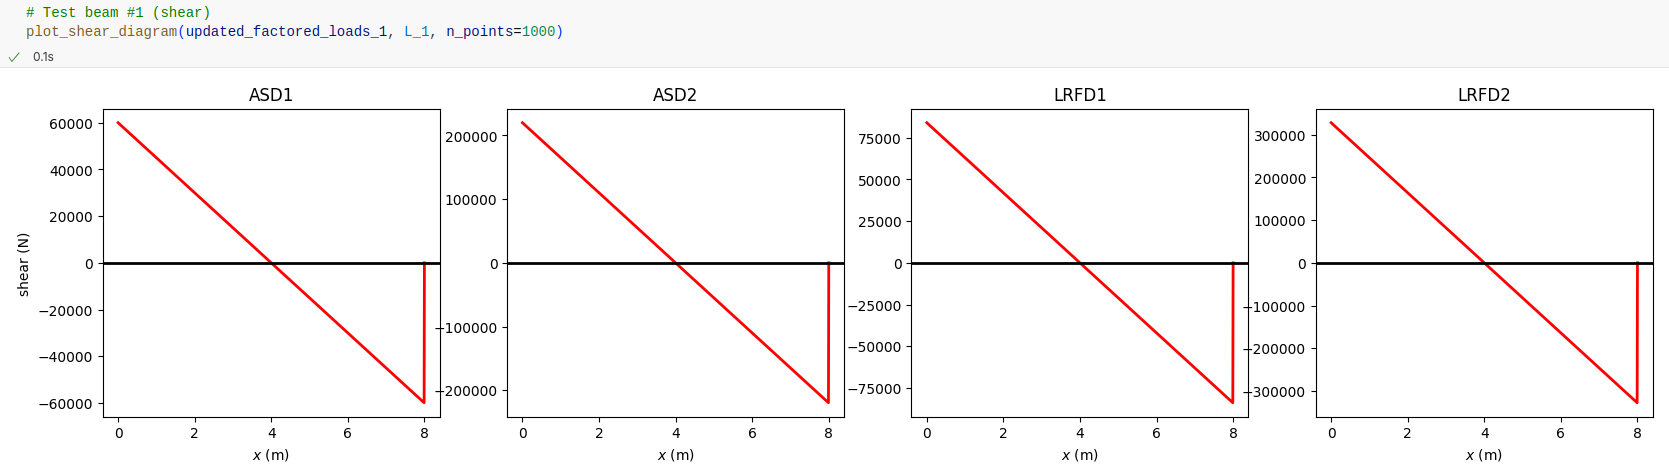
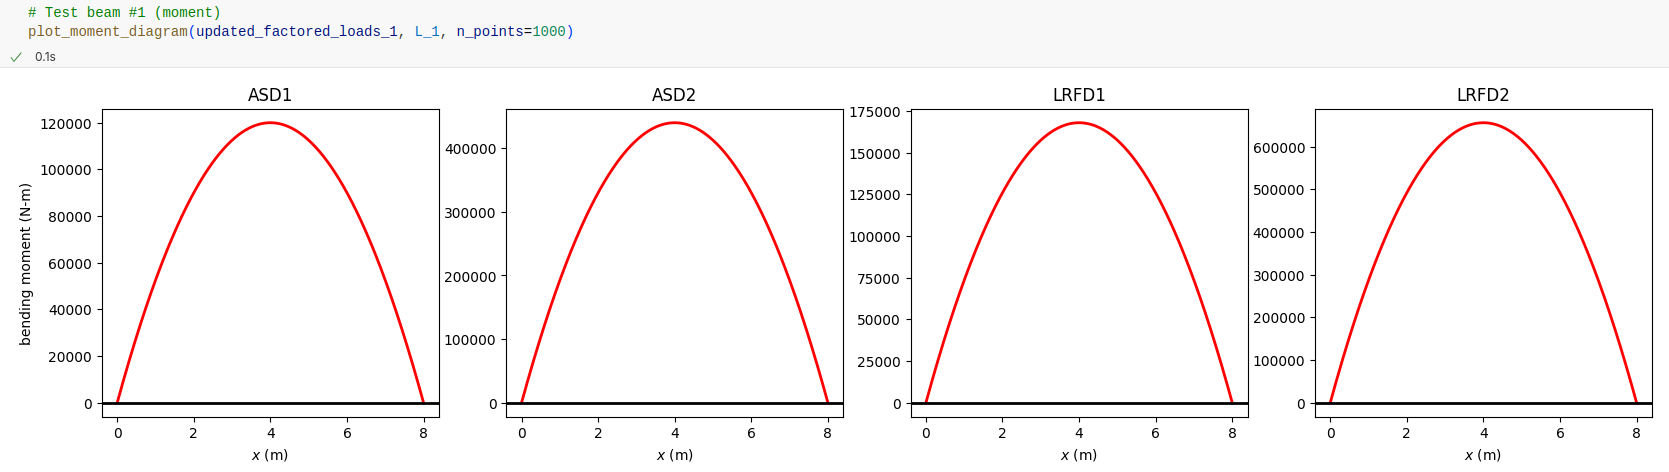

<u>*Test beam #2*</u>

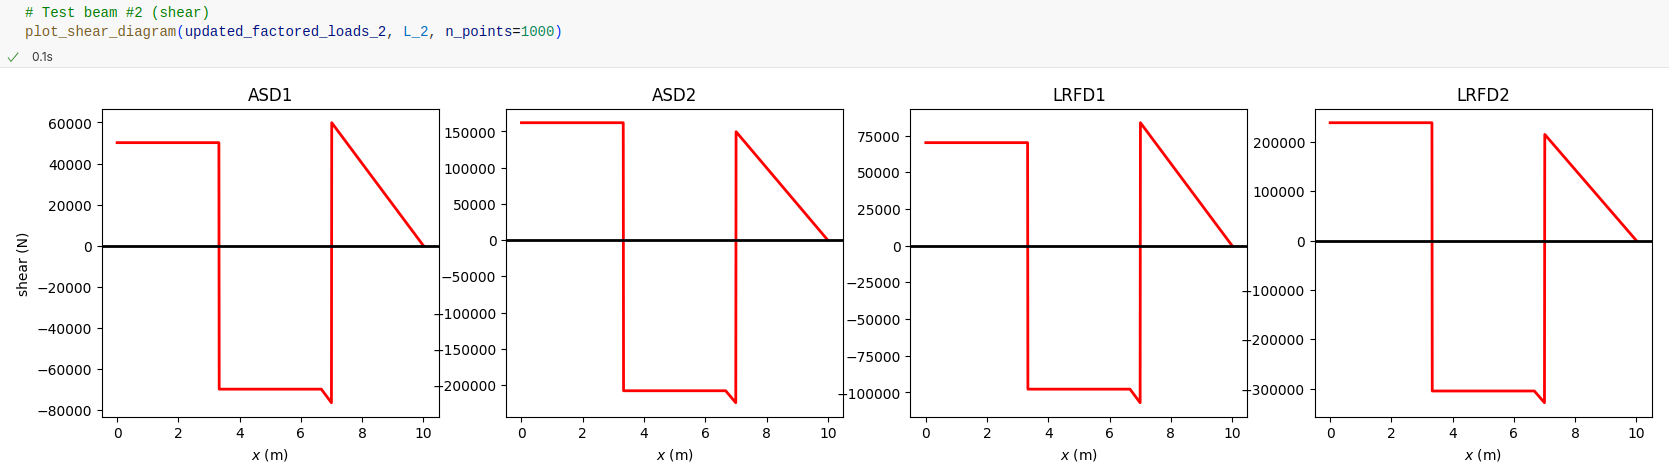
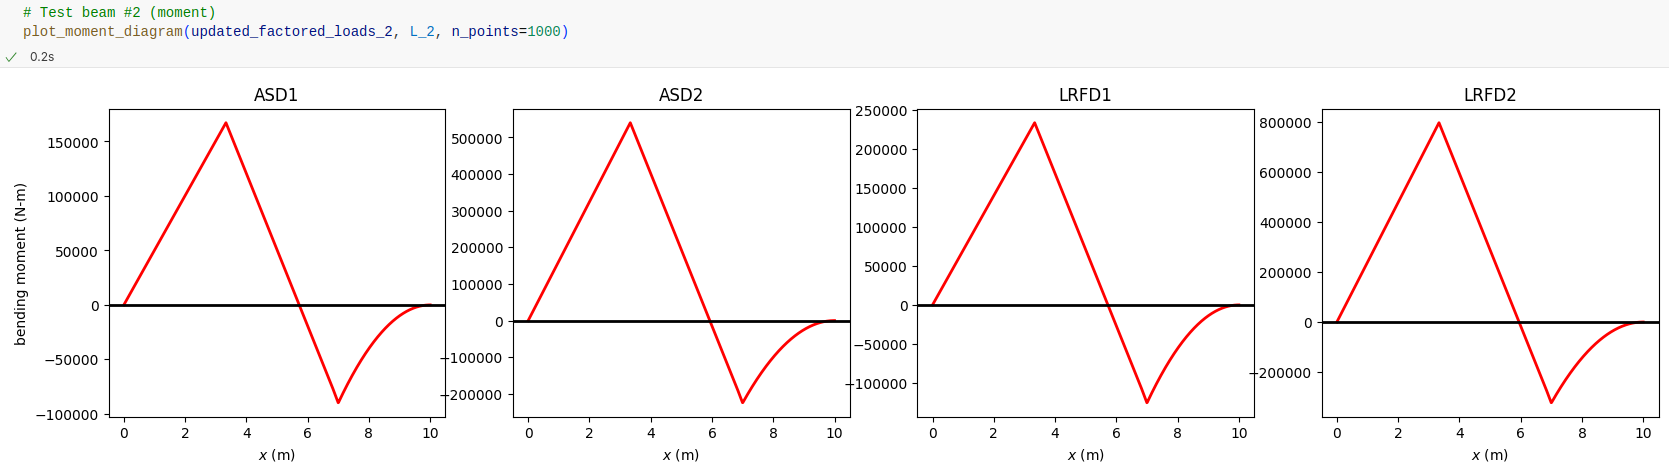

<u>*Test beam #3*</u>

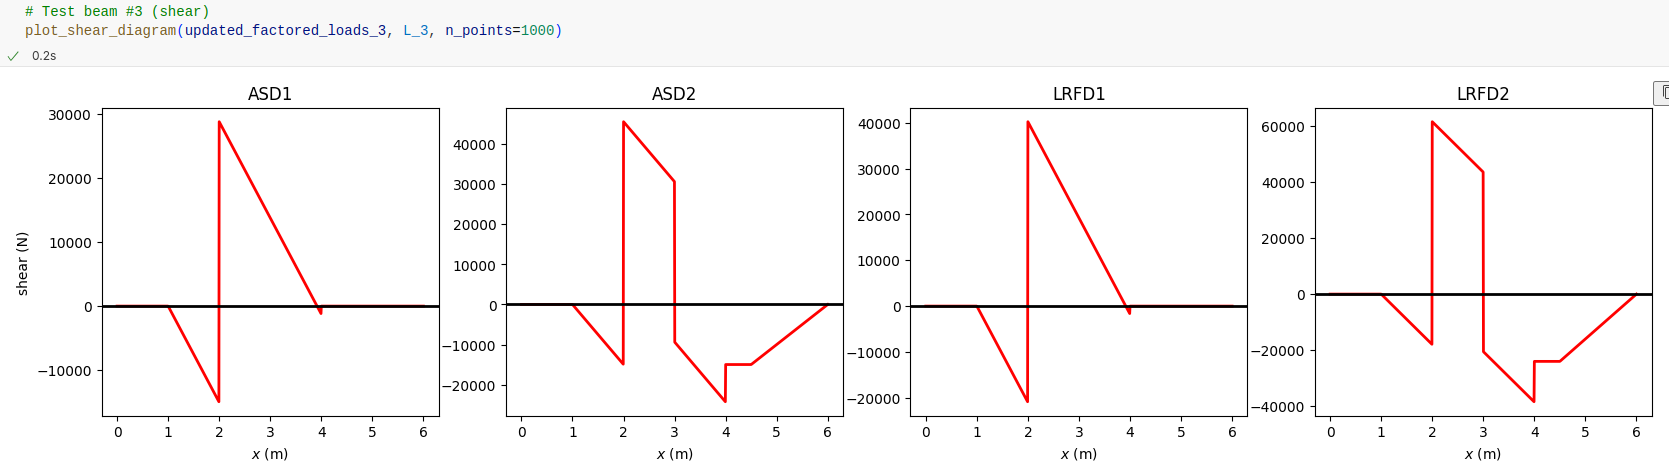
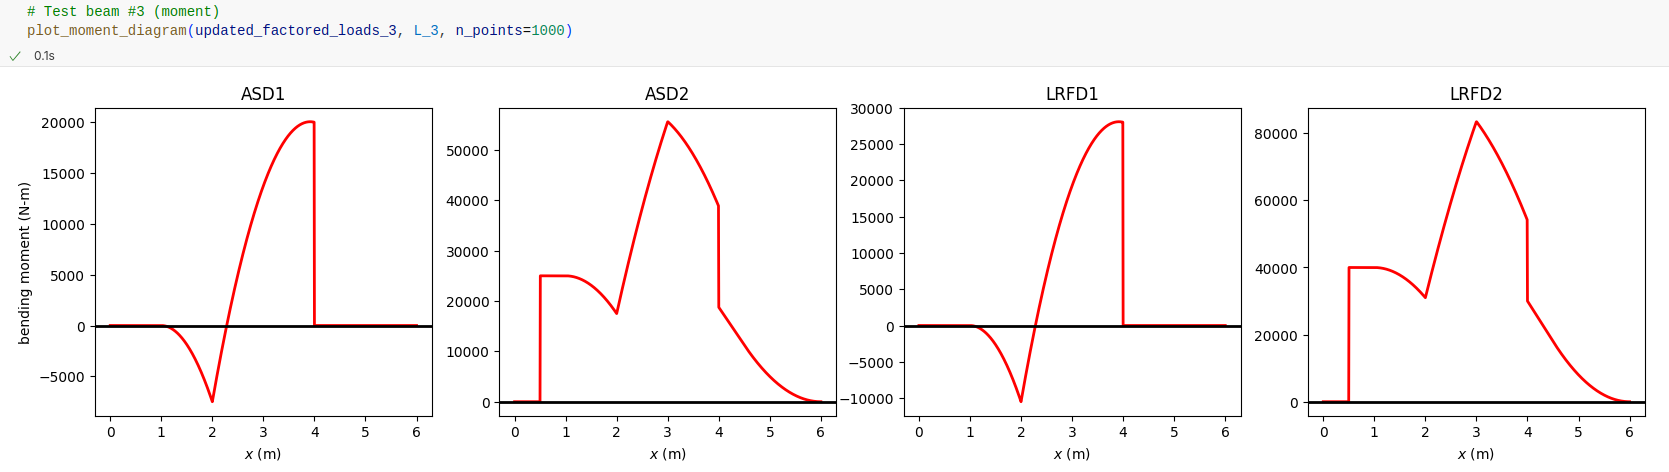

In [ ]:
def plot_shear_diagram(updated_factored_loads, L, n_points=100) :
    #
    # Place your code here
    #

    return None

def plot_moment_diagram(updated_factored_loads, L, n_points=100) :
    #
    # Place your code here 
    #
    
    return None

In [ ]:
# Test beam #1 (shear)
plot_shear_diagram(updated_factored_loads_1, L_1, n_points=1000)

In [ ]:
# Test beam #1 (moment)
plot_moment_diagram(updated_factored_loads_1, L_1, n_points=1000)

In [ ]:
# Test beam #2 (shear)
plot_shear_diagram(updated_factored_loads_2, L_2, n_points=1000)

In [ ]:
# Test beam #2 (moment)
plot_moment_diagram(updated_factored_loads_2, L_2, n_points=1000)

In [ ]:
# Test beam #3 (shear)
plot_shear_diagram(updated_factored_loads_3, L_3, n_points=1000)

In [ ]:
# Test beam #3 (moment)
plot_moment_diagram(updated_factored_loads_3, L_3, n_points=1000)

##### **Problem 4** (40 points)

**Part A.** Create a function called `rc_design_beam_size` which takes `Mu_max` (in N-mm), `fcp` (in MPa), `fy` (in MPa), `cc` (in mm), `db` (in mm) and `dst` (in mm) as required arguments, and `aspectratio` as an optional argument with default value 2. Here, `Mu_max` is the maximum bending moment within the beam for the load envelope of `lrfd1` and `lrfd2`; while `aspectratio` is the ratio $\displaystyle \frac{h}{b}$, where $b$ and $h$ are the width and total depth of the beam, respectively. The function shall return a tuple `(b, h)`, where `b` and `h` are rounded to the next higher 50 mm. Please also take note of the following:
- $b,h\geqslant 200\text{ mm}$
- The function shall give the **smallest** possible size of the beam for a given aspect ratio (i.e. values of $b$ and $h$).
- The resulting beam size shall lead to a tension-controlled behavior of the beam.
- Use NSCP 2015 provisions.

Refer to the figures below for examples.

<u>*Test beam #1*</u>

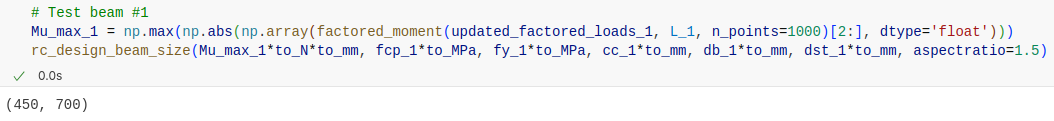

<u>*Test beam #2*</u>

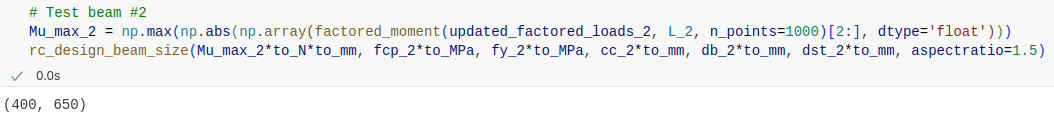

<u>*Test beam #3*</u>

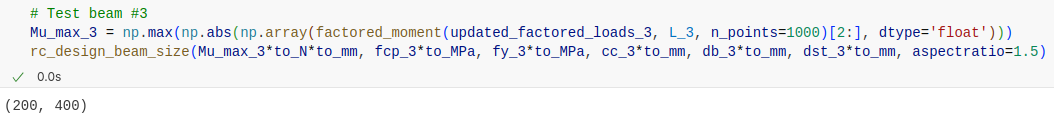

In [ ]:
def rc_design_beam_size(Mu_max, fcp, fy, cc, db, dst, aspectratio=2) :
    #
    # Place your code here.
    #

    return (b, h)

In [ ]:
# Test beam #1
Mu_max_1 = np.max(np.abs(np.array(factored_moment(updated_factored_loads_1, L_1, n_points=1000)[2:], dtype='float')))
beam_size_1 = rc_design_beam_size(Mu_max_1*to_N*to_mm, fcp_1*to_MPa, fy_1*to_MPa, cc_1*to_mm, db_1*to_mm, dst_1*to_mm, aspectratio=1.5)
print(beam_size_1)

In [ ]:
# Test beam #2
Mu_max_2 = np.max(np.abs(np.array(factored_moment(updated_factored_loads_2, L_2, n_points=1000)[2:], dtype='float')))
beam_size_2 = rc_design_beam_size(Mu_max_2*to_N*to_mm, fcp_2*to_MPa, fy_2*to_MPa, cc_2*to_mm, db_2*to_mm, dst_2*to_mm, aspectratio=1.5)
print(beam_size_2)

In [ ]:
# Test beam #3
Mu_max_3 = np.max(np.abs(np.array(factored_moment(updated_factored_loads_3, L_3, n_points=1000)[2:], dtype='float')))
beam_size_3 = rc_design_beam_size(Mu_max_3*to_N*to_mm, fcp_3*to_MPa, fy_3*to_MPa, cc_3*to_mm, db_3*to_mm, dst_3*to_mm, aspectratio=1.5)
print(beam_size_3)

**Part B.** Create a function called `rc_design_beam_main` which takes `bending_moments` (in N-mm), `b` (in mm), `h` (in mm), `fcp` (in MPa), `fy` (in MPa), `cc` (in mm), `db` (in mm) and `dst` (in mm) as required arguments. Here, `bending_moments` (a list) shall be the bending moment for the load envelope of `lrfd1` and `lrfd2` for each point on the beam as defined in Problem 3 Part C; while `b` and `h` shall come from the results of Problem 4 Part A. 

The function shall return a tuple `(As_req, Asp_req)`, which contains the required tension reinforcement area for each point on the beam as defined in Problem 3 Part C. Here, `As_req` is the reinforcement in portions with positive moments (taken to be zero for negative moments), while `As_req` is the reinforcement in portions with negative moments (taken to be zero for positive moments). All reinforcement areas are in units of $\text{mm}^2$.

- Use NSCP 2015 provisions.
- Assume the rebars can fit in one layer of reinforcement.

Refer to the figures below for examples.

<u>*Test beam #1*</u>

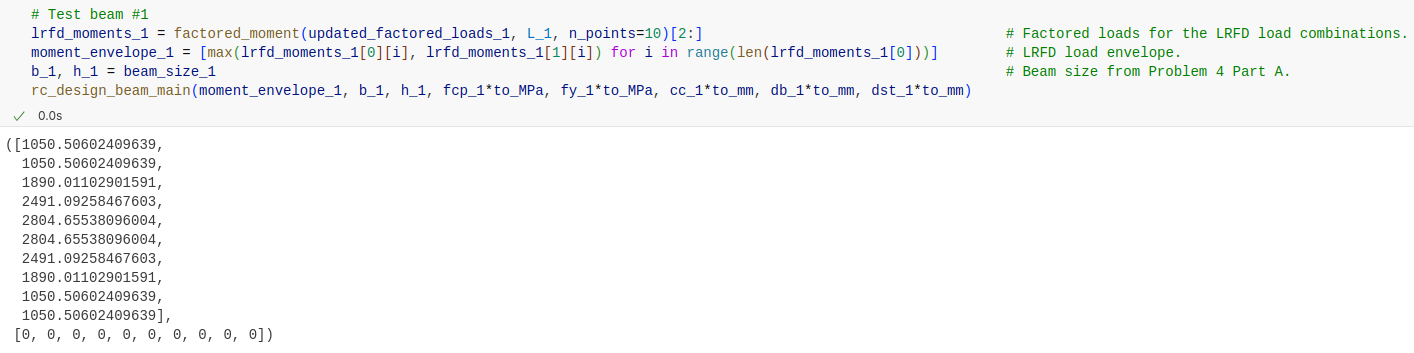

<u>*Test beam #2*</u>

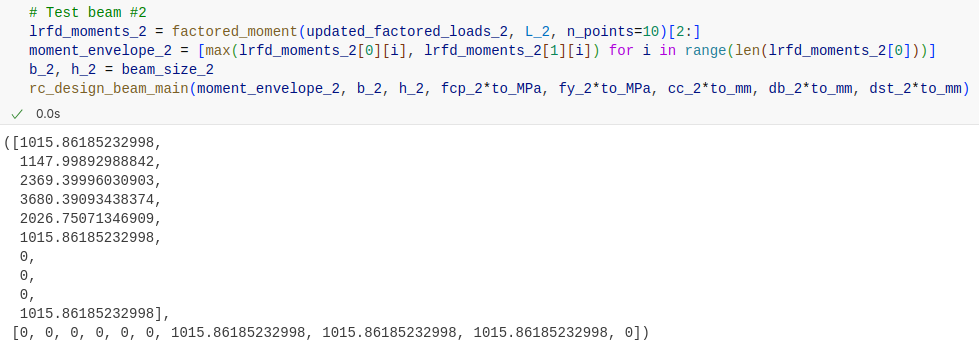

<u>*Test beam #3*</u>

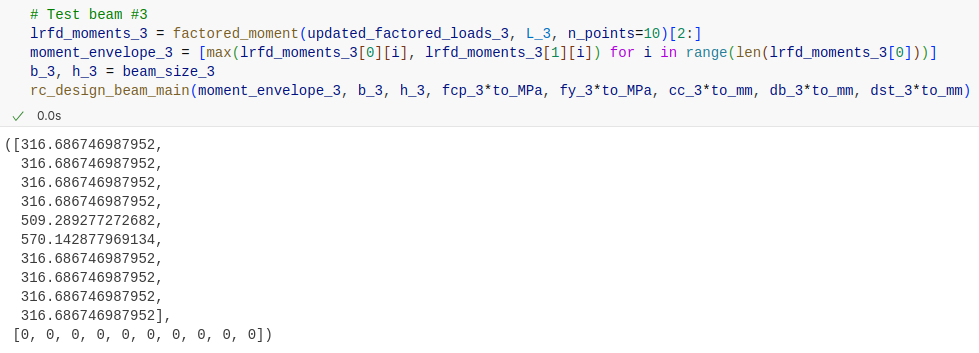

In [ ]:
#
# Get the load envelope of lrfd1 and lrfd2 bending moments.
# Place your code here.
#

def rc_design_beam_main(bending_moments, b, h, fcp, fy, cc, db, dst) :
    #
    # Get the rebar area at each point on the beam.
    # Place your code here.
    #

    return (As_req, Asp_req)

In [ ]:
# Test beam #1
lrfd_moments_1 = factored_moment(updated_factored_loads_1, L_1, n_points=10)[2:]                                    # Factored loads for the LRFD load combinations.
moment_envelope_1 = [max(lrfd_moments_1[0][i], lrfd_moments_1[1][i]) for i in range(len(lrfd_moments_1[0]))]        # LRFD load envelope.
b_1, h_1 = beam_size_1                                                                                              # Beam size from Problem 4 Part A.
rc_design_beam_main(moment_envelope_1, b_1, h_1, fcp_1*to_MPa, fy_1*to_MPa, cc_1*to_mm, db_1*to_mm, dst_1*to_mm)

In [ ]:
# Test beam #2
lrfd_moments_2 = factored_moment(updated_factored_loads_2, L_2, n_points=10)[2:]
moment_envelope_2 = [max(lrfd_moments_2[0][i], lrfd_moments_2[1][i]) for i in range(len(lrfd_moments_2[0]))]
b_2, h_2 = beam_size_2
rc_design_beam_main(moment_envelope_2, b_2, h_2, fcp_2*to_MPa, fy_2*to_MPa, cc_2*to_mm, db_2*to_mm, dst_2*to_mm)

In [ ]:
# Test beam #3
lrfd_moments_3 = factored_moment(updated_factored_loads_3, L_3, n_points=10)[2:]
moment_envelope_3 = [max(lrfd_moments_3[0][i], lrfd_moments_3[1][i]) for i in range(len(lrfd_moments_3[0]))]
b_3, h_3 = beam_size_3
rc_design_beam_main(moment_envelope_3, b_3, h_3, fcp_3*to_MPa, fy_3*to_MPa, cc_3*to_mm, db_3*to_mm, dst_3*to_mm)

**Part C.** Create a function called `plot_main_rebar` that takes three required arguments `L`, `As_req` and `Asp_req` and returns a plot of `As_req` and `Asp_req` in a single plot window, with `As_req` at the bottom and `Asp_req` at the top. Use `matplotlib` or `plotly` to do the plotting and customize it as you see fit. Add identifiers to indicate top bars and bottom bars in the plot.

Refer to the figures below for examples.

<u>*Test beam #1*</u>

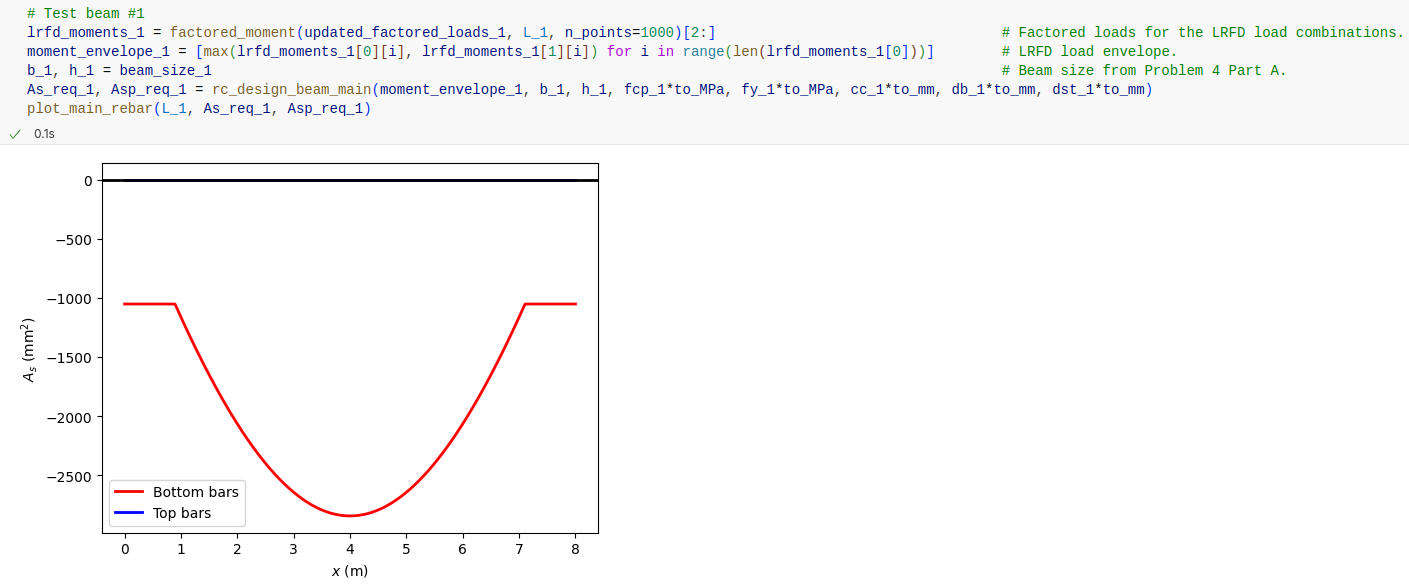

<u>*Test beam #2*</u>

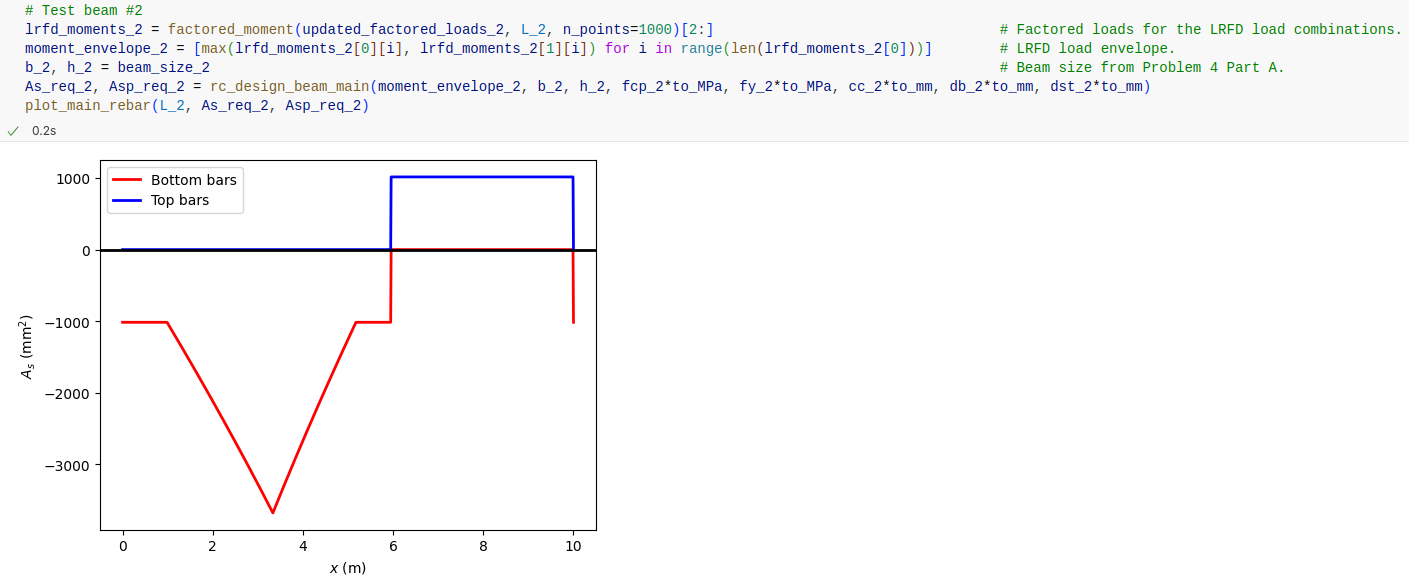

<u>*Test beam #3*</u>

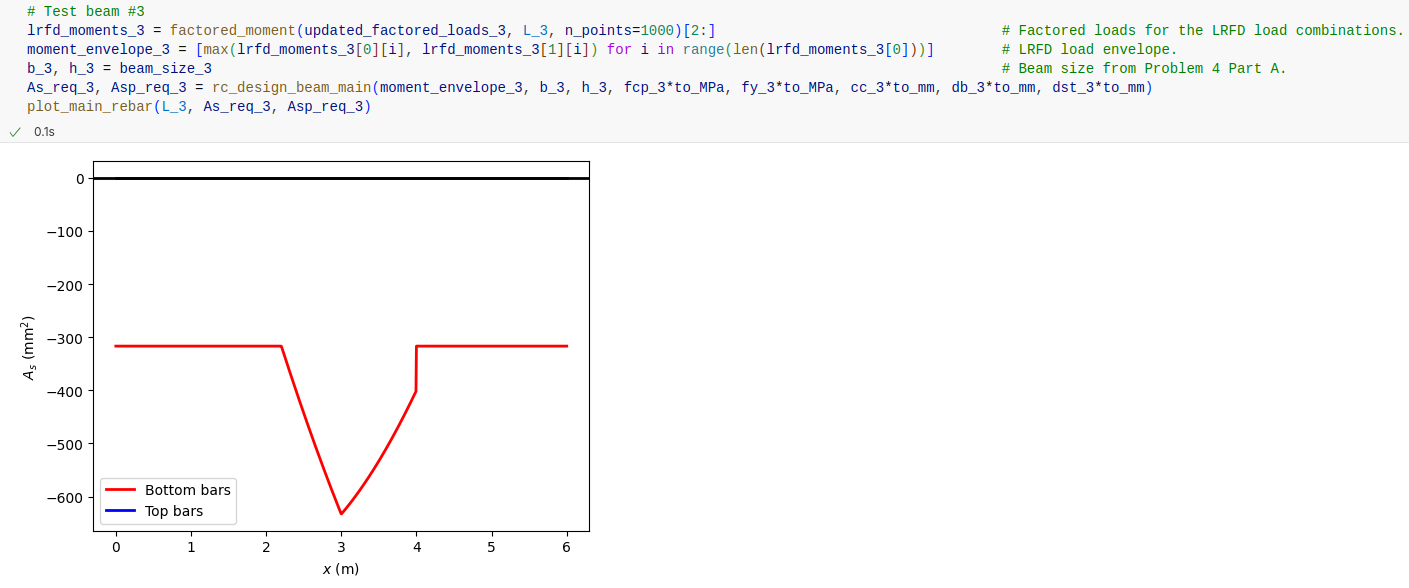

In [ ]:
def plot_main_rebar(L, As_req, Asp_req) :
    #
    # Place your code here.
    #

    return None

In [ ]:
# Test beam #1
lrfd_moments_1 = factored_moment(updated_factored_loads_1, L_1, n_points=1000)[2:]                                  # Factored loads for the LRFD load combinations.
moment_envelope_1 = [max(lrfd_moments_1[0][i], lrfd_moments_1[1][i]) for i in range(len(lrfd_moments_1[0]))]        # LRFD load envelope.
b_1, h_1 = beam_size_1                                                                                              # Beam size from Problem 4 Part A.
As_req_1, Asp_req_1 = rc_design_beam_main(moment_envelope_1, b_1, h_1, fcp_1*to_MPa, fy_1*to_MPa, cc_1*to_mm, db_1*to_mm, dst_1*to_mm)
plot_main_rebar(L_1, As_req_1, Asp_req_1)

In [ ]:
# Test beam #2
lrfd_moments_2 = factored_moment(updated_factored_loads_2, L_2, n_points=1000)[2:]                                  # Factored loads for the LRFD load combinations.
moment_envelope_2 = [max(lrfd_moments_2[0][i], lrfd_moments_2[1][i]) for i in range(len(lrfd_moments_2[0]))]        # LRFD load envelope.
b_2, h_2 = beam_size_2                                                                                              # Beam size from Problem 4 Part A.
As_req_2, Asp_req_2 = rc_design_beam_main(moment_envelope_2, b_2, h_2, fcp_2*to_MPa, fy_2*to_MPa, cc_2*to_mm, db_2*to_mm, dst_2*to_mm)
plot_main_rebar(L_2, As_req_2, Asp_req_2)

In [ ]:
# Test beam #3
lrfd_moments_3 = factored_moment(updated_factored_loads_3, L_3, n_points=1000)[2:]                                  # Factored loads for the LRFD load combinations.
moment_envelope_3 = [max(lrfd_moments_3[0][i], lrfd_moments_3[1][i]) for i in range(len(lrfd_moments_3[0]))]        # LRFD load envelope.
b_3, h_3 = beam_size_3                                                                                              # Beam size from Problem 4 Part A.
As_req_3, Asp_req_3 = rc_design_beam_main(moment_envelope_3, b_3, h_3, fcp_3*to_MPa, fy_3*to_MPa, cc_3*to_mm, db_3*to_mm, dst_3*to_mm)
plot_main_rebar(L_3, As_req_3, Asp_req_3)

**For Plus Points** This final exercise is a free-to-do-anything-you-want challenge. 

Create a function called `plot_deflection` that takes as many arguments as you want it to be, and returns the plot of the deflected shape of the beam. Use `matplotlib` or `plotly` to do the visualization, and you can customize your plot in any way you want. 

There are no examples for this part, so you have to release your inner manual computation and experience powers to check if your code is correct.

In [ ]:
def plot_deflection(#Enter the arguments for this function here.#) :
    #
    # Place your code here.
    #

    return #Enter the return value here.#

### <center>**END OF DAY 3 PROGRAMMING COMPETITION**</center>